In [ ]:
from pathlib import Path
import kagglehub 

DATASET_ROOT = Path("kaggle_dataset")

downloaded_path = kagglehub.dataset_download(
    "ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes",
    output_dir=str(DATASET_ROOT),
    force_download=True,
)
print("Downloaded to:", downloaded_path)
# KaggleHub writes directly into DATASET_ROOT when output_dir is set.

train_path = DATASET_ROOT / "Train"
val_path = DATASET_ROOT / "Val"
test_path = DATASET_ROOT / "Test"

# Remove stale Ultralytics label caches so labels are always freshly scanned
removed = 0
for cache_file in DATASET_ROOT.rglob("*.cache"):
    cache_file.unlink()
    removed += 1
print(f"Removed {removed} stale .cache file(s)")

print("train_path:", train_path)
print("val_path:", val_path)
print("test_path:", test_path)


100%|██████████| 133M/133M [00:14<00:00, 9.91MB/s] 

Extracting files...


Downloaded to: D:\Programs\Work_in_progress\brain_tumor_detection\kaggle_dataset
Removed 0 stale .cache file(s)
train_path: D:\Programs\Work_in_progress\brain_tumor_detection\kaggle_dataset\Train
val_path: D:\Programs\Work_in_progress\brain_tumor_detection\kaggle_dataset\Val
test_path: D:\Programs\Work_in_progress\brain_tumor_detection\kaggle_dataset\Test


In [47]:
classes = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
class_to_id = {c: i for i, c in enumerate(classes)}

In [ ]:
import pandas as pd
import plotly.graph_objects as go

DATASET_ROOT = Path("kaggle_dataset")
train_path = DATASET_ROOT / "Train"
val_path = DATASET_ROOT / "Val"

def count_per_class(split_path):
    return [len(list((Path(split_path) / cls / "images").glob("*"))) for cls in classes]

eda_df = pd.DataFrame({
    "Class": classes,
    "Train": count_per_class(train_path),
    "Validation": count_per_class(val_path),
})
print(eda_df)

fig = go.Figure(data=[
    go.Bar(name="Train", x=eda_df["Class"], y=eda_df["Train"]),
    go.Bar(name="Validation", x=eda_df["Class"], y=eda_df["Validation"]),
])
fig.update_layout(barmode="group", title="Class Distribution Across Splits")
fig.show()


        Class  Train  Validation
0      Glioma   1153         136
1  Meningioma   1449         140
2    No Tumor    711         100
3   Pituitary   1424         136


In [ ]:
import shutil, random
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATASET_ROOT    = Path("kaggle_dataset")
NEW_ROOT        = Path("dataset")   
CLASSES         = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
VAL_RATIO       = 0.10   
TEST_RATIO      = 0.10   
SEED            = 42
# ─────────────────────────────────────────────────────────────────────────────

random.seed(SEED)

# Step 1 - collect all (image_path, label_path) pairs per class across ALL splits
all_pairs = {cls: [] for cls in CLASSES}

for split in ["Train", "Val", "Test"]:
    for cls in CLASSES:
        img_dir   = DATASET_ROOT / split / cls / "images"
        lbl_dir   = DATASET_ROOT / split / cls / "labels"
        if not img_dir.exists():
            continue
        for img_path in sorted(img_dir.glob("*")):
            if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
                continue
            lbl_path = lbl_dir / (img_path.stem + ".txt")
            if lbl_path.exists():          
                all_pairs[cls].append((img_path, lbl_path))

# Step 2 - stratified shuffle-split
split_counts = {}
for cls, pairs in all_pairs.items():
    random.shuffle(pairs)
    n       = len(pairs)
    n_val   = max(1, int(n * VAL_RATIO))
    n_test  = max(1, int(n * TEST_RATIO))
    n_train = n - n_val - n_test
    split_counts[cls] = {"train": n_train, "val": n_val, "test": n_test, "total": n}
    all_pairs[cls] = {
        "train": pairs[:n_train],
        "val":   pairs[n_train:n_train + n_val],
        "test":  pairs[n_train + n_val:],
    }

# Step 3 - print the new distribution
print(f"{'Class':<15} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>7}")
print("-" * 45)
for cls in CLASSES:
    c = split_counts[cls]
    print(f"{cls:<15} {c['train']:>7} {c['val']:>7} {c['test']:>7} {c['total']:>7}")

# Step 4 - copy files into new structure
if NEW_ROOT.exists():
    shutil.rmtree(NEW_ROOT)    # clean slate

for split_name in ["train", "val", "test"]:
    for cls in CLASSES:
        (NEW_ROOT / split_name.capitalize() / cls / "images").mkdir(parents=True, exist_ok=True)
        (NEW_ROOT / split_name.capitalize() / cls / "labels").mkdir(parents=True, exist_ok=True)
        for img_path, lbl_path in all_pairs[cls][split_name]:
            shutil.copy2(img_path, NEW_ROOT / split_name.capitalize() / cls / "images" / img_path.name)
            shutil.copy2(lbl_path, NEW_ROOT / split_name.capitalize() / cls / "labels" / lbl_path.name)

print(f"\nDone! New dataset written to: {NEW_ROOT.resolve()}")
print("Update dataset.yaml to point to dataset_resplit/ before retraining.")


Class             Train     Val    Test   Total
---------------------------------------------
Glioma             1033     128     128    1289
Meningioma         1273     158     158    1589
No Tumor            649      80      80     809
Pituitary          1248     156     156    1560

Done! New dataset written to: D:\Programs\Work_in_progress\brain_tumor_detection\dataset
Update dataset.yaml to point to dataset_resplit/ before retraining.


In [ ]:
import pandas as pd
import plotly.graph_objects as go

DATASET_ROOT = Path("dataset")
train_path = DATASET_ROOT / "Train"
val_path = DATASET_ROOT / "Val"
test_path = DATASET_ROOT / "Test"

def count_per_class(split_path):
    return [len(list((Path(split_path) / cls / "images").glob("*"))) for cls in classes]

eda_df = pd.DataFrame({
    "Class": classes,
    "Train": count_per_class(train_path),
    "Validation": count_per_class(val_path),
    "Test": count_per_class(test_path),
})
print(eda_df)

fig = go.Figure(data=[
    go.Bar(name="Train", x=eda_df["Class"], y=eda_df["Train"]),
    go.Bar(name="Validation", x=eda_df["Class"], y=eda_df["Validation"]),
    go.Bar(name="Test", x=eda_df["Class"], y=eda_df["Test"]),
])
fig.update_layout(barmode="group", title="Class Distribution Across Splits")
fig.show()


        Class  Train  Validation  Test
0      Glioma   1033         128   128
1  Meningioma   1273         158   158
2    No Tumor    649          80    80
3   Pituitary   1248         156   156


In [ ]:
def count_images_and_bboxes(split_path):
    rows = []
    for cls in classes:
        img_dir = Path(split_path) / cls / "images"
        label_dir = Path(split_path) / cls / "labels"
        image_files = [p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
        bbox_instances = 0
        for img_path in image_files:
            label_path = label_dir / (img_path.stem + ".txt")
            if label_path.exists():
                bbox_instances += sum(1 for line in label_path.read_text().splitlines() if line.strip())
        rows.append({
            "Class": cls,
            "Split": Path(split_path).name,
            "Images": len(image_files),
            "BBox Instances": bbox_instances,
        })
    return pd.DataFrame(rows)

counts_df = pd.concat([
    count_images_and_bboxes(train_path),
    count_images_and_bboxes(val_path),
    count_images_and_bboxes(test_path),
], ignore_index=True)

print("Image and bounding-box instance counts per class across splits:")
print(counts_df)

counts_table = counts_df.pivot(index="Class", columns="Split", values=["Images", "BBox Instances"])
counts_table.loc["Total"] = counts_table.sum(axis=0)
print("\nPivoted summary:")
print(counts_table)


Image and bounding-box instance counts per class across splits:
         Class  Split  Images  BBox Instances
0       Glioma  Train     894            1037
1   Meningioma  Train    1189            1216
2     No Tumor  Train     649             649
3    Pituitary  Train    1247            1330
4       Glioma    Val     111             126
5   Meningioma    Val     146             151
6     No Tumor    Val      80              80
7    Pituitary    Val     156             167
8       Glioma   Test     119             148
9   Meningioma   Test     148             151
10    No Tumor   Test      80              80
11   Pituitary   Test     156             166

Pivoted summary:
           Images            BBox Instances           
Split        Test Train  Val           Test Train  Val
Class                                                 
Glioma        119   894  111            148  1037  126
Meningioma    148  1189  146            151  1216  151
No Tumor       80   649   80             80  

: 

In [51]:
import pandas as pd

def audit_split(split_path, split_name):
    rows = []
    for cls in classes:
        expected_id = class_to_id[cls]
        labels_dir = Path(split_path) / cls / "labels"
        if not labels_dir.exists():
            continue
        for label_file in sorted(labels_dir.glob("*.txt")):
            lines = [l.strip() for l in label_file.read_text().splitlines() if l.strip()]
            ids_in_file = sorted(set(int(float(l.split()[0])) for l in lines)) if lines else []
            rows.append({
                "split": split_name,
                "folder_class": cls,
                "expected_id": expected_id,
                "file": str(label_file),
                "n_boxes": len(lines),
                "ids_found": ids_in_file,
                "is_empty": len(lines) == 0,
                "is_mismatched": len(ids_in_file) > 0 and any(i != expected_id for i in ids_in_file),
            })
    return pd.DataFrame(rows)

audit_df = pd.concat([
    audit_split(train_path, "train"),
    audit_split(val_path, "val"),
    audit_split(test_path, "test"),
], ignore_index=True)

print("Total label files audited:", len(audit_df))
print("Empty label files:", audit_df["is_empty"].sum())
print("Multi-box files:", (audit_df["n_boxes"] > 1).sum())
print("Mismatched files (folder vs label class):", audit_df["is_mismatched"].sum())
print()
print("Mismatches by split / folder class:")
print(audit_df[audit_df["is_mismatched"]].groupby(["split", "folder_class"]).size())

mismatch_report_path = "label_mismatch_report.csv"
audit_df[audit_df["is_mismatched"]].to_csv(mismatch_report_path, index=False)
print(f"\nFull mismatch report saved to: {mismatch_report_path}")


Total label files audited: 5247
Empty label files: 1
Multi-box files: 549
Mismatched files (folder vs label class): 272

Mismatches by split / folder class:
split  folder_class
test   Glioma            9
       Meningioma       10
train  Glioma          139
       Meningioma       84
       Pituitary         1
val    Glioma           17
       Meningioma       12
dtype: int64

Full mismatch report saved to: label_mismatch_report.csv


In [52]:
DROP_MISMATCHED = True

if DROP_MISMATCHED:
    excluded_files = set(audit_df.loc[audit_df["is_mismatched"], "file"])
    print(f"Will exclude {len(excluded_files)} mismatched label files (and their images) from training.")
    for label_file in excluded_files:
        label_path = Path(label_file)
        img_dir = label_path.parent.parent / "images"
        candidates = list(img_dir.glob(label_path.stem + ".*"))
        label_path.rename(label_path.with_suffix(label_path.suffix + ".excluded"))
        for img_path in candidates:
            img_path.rename(img_path.with_suffix(img_path.suffix + ".excluded"))
    print("Done. Excluded files carry a '.excluded' suffix and are ignored by Ultralytics' file globbing.")
else:
    print("Keeping all files, including flagged mismatches.")


Will exclude 272 mismatched label files (and their images) from training.
Done. Excluded files carry a '.excluded' suffix and are ignored by Ultralytics' file globbing.


In [53]:
import random
import cv2
import numpy as np

def load_sample(data_path, n_per_class=6):
    images, labels_per_image, img_paths = [], [], []
    for cls in classes:
        img_dir = Path(data_path) / cls / "images"
        label_dir = Path(data_path) / cls / "labels"
        candidates = [p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
        sample = random.sample(candidates, min(n_per_class, len(candidates)))
        for img_path in sample:
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            label_path = label_dir / (img_path.stem + ".txt")
            boxes = []
            if label_path.exists():
                for line in label_path.read_text().splitlines():
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    boxes.append((float(parts[0]), *map(float, parts[1:5])))  # ALL lines, not just the first
            images.append(img)
            labels_per_image.append(boxes)
            img_paths.append(img_path)
    return images, labels_per_image, img_paths

train_sample_images, train_sample_labels, train_sample_paths = load_sample(train_path, n_per_class=6)
print(f"Loaded {len(train_sample_images)} sample images for visualization "
      f"(avg {np.mean([len(b) for b in train_sample_labels]):.2f} boxes/image)")


Loaded 24 sample images for visualization (avg 1.08 boxes/image)


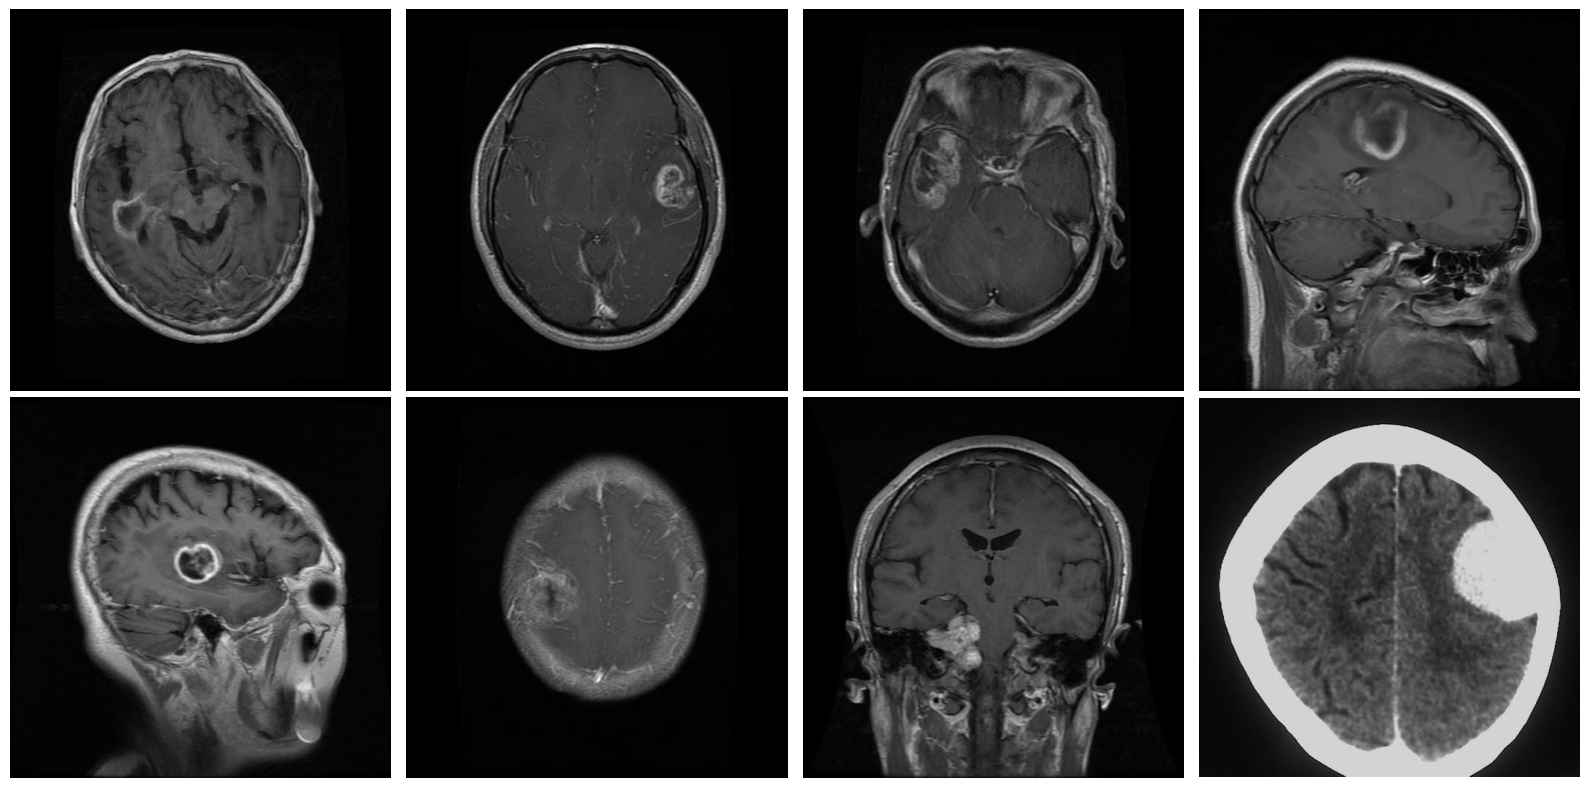

In [54]:
import matplotlib.pyplot as plt

# Visualize a few raw images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, img in zip(axes.flat, train_sample_images[:8]):
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()


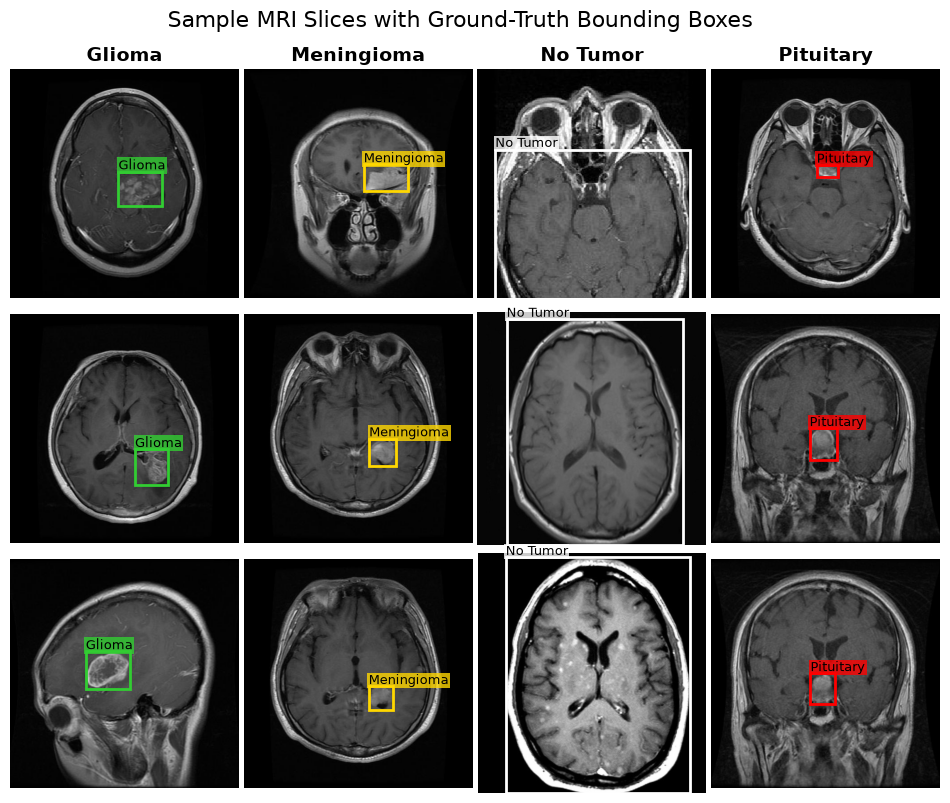

In [55]:
from matplotlib.patches import Rectangle

id_to_class = {v: k for k, v in class_to_id.items()}
class_colors = {
    "Glioma": "limegreen",
    "Meningioma": "gold",
    "No Tumor": "white",
    "Pituitary": "red",
}

def collect_class_samples(split_paths, samples_per_class=3):
    class_samples = {cls: [] for cls in classes}
    for split_path in split_paths:
        for cls in classes:
            img_dir = Path(split_path) / cls / "images"
            label_dir = Path(split_path) / cls / "labels"
            if not img_dir.exists():
                continue
            for img_path in sorted(img_dir.glob("*")):
                if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
                    continue
                label_path = label_dir / (img_path.stem + ".txt")
                boxes = []
                if label_path.exists():
                    for line in label_path.read_text().splitlines():
                        line = line.strip()
                        if not line:
                            continue
                        parts = line.split()
                        boxes.append((float(parts[0]), *map(float, parts[1:5])))
                if boxes or cls == "No Tumor":
                    img = cv2.imread(str(img_path))
                    if img is None:
                        continue
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    class_samples[cls].append((img, boxes, img_path.stem))
    for cls in classes:
        class_samples[cls] = class_samples[cls][:samples_per_class]
    return class_samples

def draw_ground_truth_boxes(ax, image, boxes):
    ax.imshow(image)
    h, w = image.shape[:2]
    for cls_id, x_center, y_center, box_w, box_h in boxes:
        cls_id = int(cls_id)
        x1 = (x_center - box_w / 2) * w
        y1 = (y_center - box_h / 2) * h
        rect_w = box_w * w
        rect_h = box_h * h
        color = class_colors.get(id_to_class.get(cls_id, ""), "lime")
        ax.add_patch(Rectangle((x1, y1), rect_w, rect_h, fill=False, edgecolor=color, linewidth=2))
        label = id_to_class.get(cls_id, str(cls_id))
        ax.text(
            x1,
            max(0, y1 - 5),
            label,
            color="black",
            fontsize=9,
            bbox=dict(facecolor=color, alpha=0.8, edgecolor="none", pad=1),
        )
    ax.axis("off")

class_samples = collect_class_samples([train_path, val_path, test_path], samples_per_class=3)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for col, cls in enumerate(classes):
    samples = class_samples[cls]
    for row in range(3):
        ax = axes[row, col]
        ax.set_facecolor("black")
        if row < len(samples):
            img, boxes, stem = samples[row]
            draw_ground_truth_boxes(ax, img, boxes)
            if row == 0:
                ax.set_title(cls, fontsize=14, fontweight="bold")
        else:
            ax.axis("off")

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.subplots_adjust(wspace=0.02, hspace=0.02, top=0.92)
plt.suptitle("Sample MRI Slices with Ground-Truth Bounding Boxes", y=0.98, fontsize=16)
plt.show()


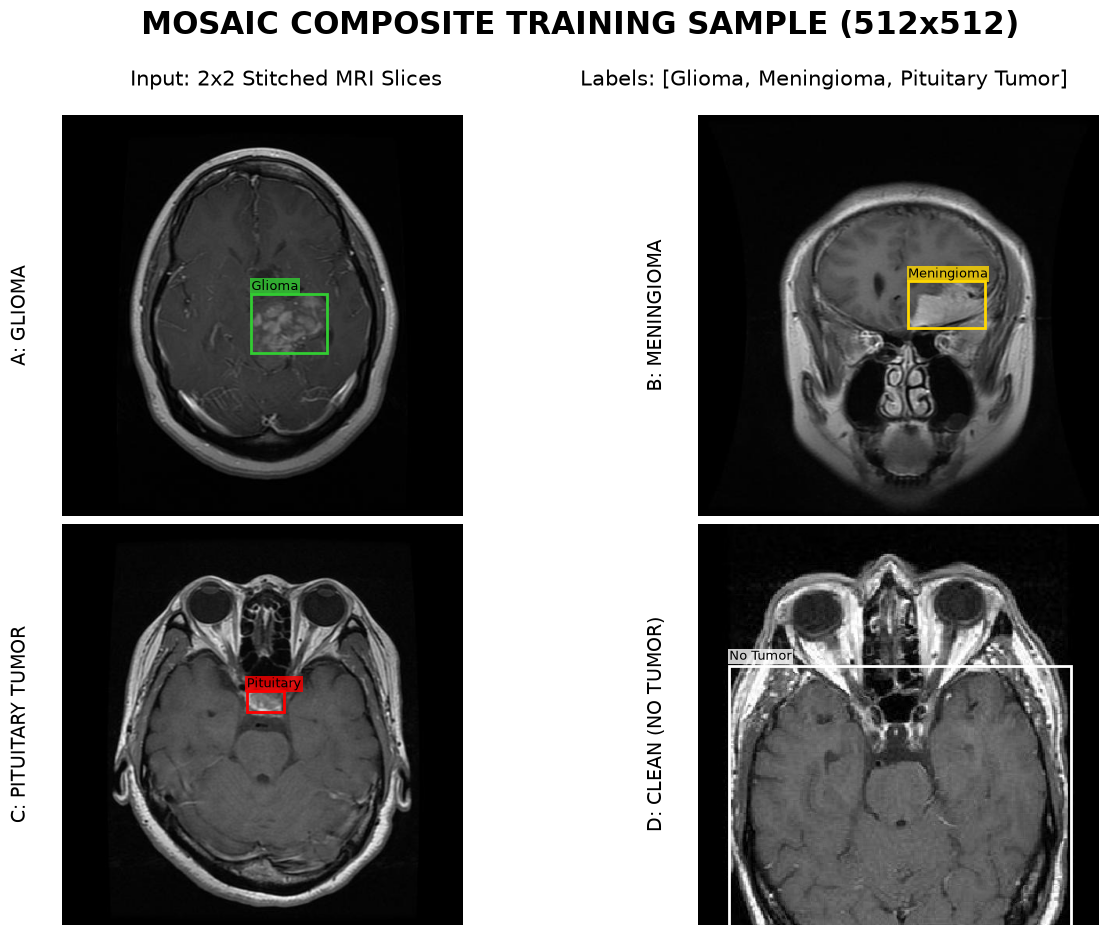

In [56]:
mosaic_labels = {
    "Glioma": "Glioma",
    "Meningioma": "Meningioma",
    "Pituitary": "Pituitary Tumor",
    "No Tumor": "Clean (No Tumor)",
}

def pick_first_sample(cls_name):
    samples = class_samples.get(cls_name, [])
    return samples[0] if samples else None

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor("white")

layout = {
    (0, 0): ("Glioma", "A: GLIOMA"),
    (0, 1): ("Meningioma", "B: MENINGIOMA"),
    (1, 0): ("Pituitary", "C: PITUITARY TUMOR"),
    (1, 1): ("No Tumor", "D: CLEAN (NO TUMOR)"),
}

for (row, col), (cls_name, side_label) in layout.items():
    ax = axes[row, col]
    sample = pick_first_sample(cls_name)
    ax.set_facecolor("black")
    if sample is not None:
        img, boxes, _ = sample
        draw_ground_truth_boxes(ax, img, boxes)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(-0.08, 0.5, side_label, transform=ax.transAxes, rotation=90,
            va="center", ha="right", fontsize=14, color="black")
    

fig.text(0.5, 0.985, "MOSAIC COMPOSITE TRAINING SAMPLE (512x512)",
         ha="center", va="top", fontsize=22, fontweight="bold")
fig.text(0.20, 0.915, "Input: 2x2 Stitched MRI Slices", ha="left", va="center", fontsize=15)
fig.text(0.50, 0.915, "Labels: [Glioma, Meningioma, Pituitary Tumor]", ha="left", va="center", fontsize=15)

plt.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.07, wspace=0.02, hspace=0.02)
plt.show()
